In [39]:
import pandas as pd
import numpy as np
#Matplotlib: Possui uma série de funções e comandos para exibição de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Missões da OTAN 

Com base neste conjunto de dados, buscamos prever o nível de sucesso das missões da OTAN.

In [40]:
df=pd.read_csv('NATO_3_Operations_Missions.csv')

As primeiras linhas do dataset

In [41]:
df.head(6)

,Record_ID,Mission_Name,Mission_Type,Lead_Country,Lead_ISO_Code,Lead_Country_Region,Operation_Location,Operation_Region,Threat_Level,Command_HQ,...,Cost_Per_Soldier_USD,Contributing_Countries_Count,NATO_Led,UN_Mandate,Mission_Outcome,Mission_Status,Classification,Media_Coverage,Public_Support_Pct,After_Action_Report
0,1,Operation Eagle Eye 00001,Logistics Support,Poland,POL,Central Europe,Barents Sea,Arctic,Medium,AIRCOM,...,2115325.83,31,Yes,No,Inconclusive,Suspended,NATO Confidential,High,90.6,Pending
1,2,Operation Loyal Leda 00002,Cyber Defense,Finland,FIN,Northern Europe,Indian Ocean,Asia,Low,ACO Mons,...,111954.09,24,Yes,Yes,Mission Accomplished,On Hold,NATO Confidential,Minimal,33.6,Classified
2,3,Operation Glacier Watch 00003,Combat,Lithuania,LTU,Northern Europe,Syria,Middle East,High,MARCOM,...,127440.28,27,Joint UN-NATO,Yes,Mission Accomplished,Suspended,NATO Restricted,High,51.5,NaN
3,4,Operation Eagle Eye 00004,Combat,Lithuania,LTU,Northern Europe,Eastern Europe,Europe,Medium,AIRCOM,...,343504.72,10,Yes,No,Suspended,Completed,NATO Secret,Low,91.8,Pending
4,5,Operation Noble Jump 00005,CBRN Response,United Kingdom,GBR,Western Europe,Western Balkans,Europe,Low,AIRCOM,...,797170.34,18,Yes,Yes,Inconclusive,On Hold,NATO Secret,Low,66.4,NaN
5,6,Operation Noble Jump 00006,Cyber Defense,United Kingdom,GBR,Western Europe,Libya,Africa,High,LANDCOM,...,90068.20,11,No,Yes,Inconclusive,On Hold,NATO Confidential,Low,59.8,Classified


As últimas linhas do dataset.

In [42]:
df.tail()

,Record_ID,Mission_Name,Mission_Type,Lead_Country,Lead_ISO_Code,Lead_Country_Region,Operation_Location,Operation_Region,Threat_Level,Command_HQ,...,Cost_Per_Soldier_USD,Contributing_Countries_Count,NATO_Led,UN_Mandate,Mission_Outcome,Mission_Status,Classification,Media_Coverage,Public_Support_Pct,After_Action_Report
5195,5196,Operation Arctic Patrol 05196,Counter-Terrorism,Latvia,LVA,Northern Europe,Black Sea,Europe,Medium,JFC Naples,...,208809.60,18,Yes,Yes,Inconclusive,On Hold,NATO Restricted,Medium,77.6,Published
5196,5197,Operation Cold Response 05197,Air Policing,Italy,ITA,Southern Europe,Somalia,Africa,Medium,LANDCOM,...,144643.60,4,Joint UN-NATO,Yes,Inconclusive,Planned,NATO Confidential,Low,44.2,NaN
5197,5198,Operation Trident Juncture 05198,Search and Rescue,Slovenia,SVN,Southern Europe,Persian Gulf,Middle East,Medium,JFC Brunssum,...,6072467.81,15,No,Yes,Transitioned to UN,On Hold,NATO Secret,Minimal,30.1,NaN
5198,5199,Operation Viking 05199,Training Exercise,Denmark,DNK,Northern Europe,Indian Ocean,Asia,Low,STRIKFORNATO,...,505762.79,7,No,No,Partially Successful,Suspended,NATO Secret,High,22.2,NaN
5199,5200,Operation Thunder Wolf 05200,Amphibious Exercise,Spain,ESP,Western Europe,Red Sea,Middle East,Medium,MARCOM,...,179673.43,12,No,Yes,Completed,On Hold,NATO Restricted,High,86.2,Published


Os tipos de dados e a contagem de valores não nulos de cada coluna.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Record_ID                     5200 non-null   int64  
 1   Mission_Name                  5200 non-null   object 
 2   Mission_Type                  5200 non-null   object 
 3   Lead_Country                  5200 non-null   object 
 4   Lead_ISO_Code                 5200 non-null   object 
 5   Lead_Country_Region           5200 non-null   object 
 6   Operation_Location            5200 non-null   object 
 7   Operation_Region              5200 non-null   object 
 8   Threat_Level                  5200 non-null   object 
 9   Command_HQ                    5200 non-null   object 
 10  Operation_Start_Year          5200 non-null   int64  
 11  Operation_End_Year            5200 non-null   int64  
 12  Duration_Years                5200 non-null   int64  
 13  Mis

Estatísticas descritivas (média, desvio padrão, quartis) das colunas numéricas.

In [44]:
df.describe()

,Record_ID,Operation_Start_Year,Operation_End_Year,Duration_Years,Troops_Deployed,Air_Assets_Deployed,Naval_Assets_Deployed,Casualties,Casualties_Rate_Pct,Mission_Cost_M_USD,Cost_Per_Soldier_USD,Contributing_Countries_Count,Public_Support_Pct
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5.200000e+03,5200.000000,5200.000000
mean,2600.500000,1985.644808,1995.168654,9.523846,37691.436154,99.267500,25.348269,743.592692,1.966177,5969.536188,6.411104e+05,17.094231,55.432154
std,1501.255031,21.784714,21.164934,5.688135,21684.326547,57.935882,14.770725,656.044687,1.156903,3458.799022,4.361454e+06,9.057380,20.961394
min,1.000000,1949.000000,1950.000000,1.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.960000,1.578000e+01,2.000000,20.000000
25%,1300.750000,1966.000000,1977.000000,5.000000,18944.000000,48.000000,13.000000,198.000000,0.953000,2994.082500,7.966557e+04,9.000000,36.800000
50%,2600.500000,1985.000000,1996.000000,9.000000,37626.500000,100.000000,26.000000,551.500000,1.956000,5941.020000,1.586784e+05,17.000000,55.300000
75%,3900.250000,2005.000000,2015.000000,14.000000,56841.500000,149.000000,38.000000,1132.000000,2.975000,8915.615000,3.124948e+05,25.000000,73.800000
max,5200.000000,2023.000000,2024.000000,20.000000,74999.000000,200.000000,50.000000,2907.000000,4.000000,11995.630000,1.536533e+08,32.000000,92.000000


O número de linhas e colunas

In [45]:
df.shape

(5200, 30)

Os nomes de todas as colunas.

In [46]:
df.columns

Index(['Record_ID', 'Mission_Name', 'Mission_Type', 'Lead_Country',
       'Lead_ISO_Code', 'Lead_Country_Region', 'Operation_Location',
       'Operation_Region', 'Threat_Level', 'Command_HQ',
       'Operation_Start_Year', 'Operation_End_Year', 'Duration_Years',
       'Mission_Phase', 'Troops_Deployed', 'Air_Assets_Deployed',
       'Naval_Assets_Deployed', 'Casualties', 'Casualties_Rate_Pct',
       'Mission_Cost_M_USD', 'Cost_Per_Soldier_USD',
       'Contributing_Countries_Count', 'NATO_Led', 'UN_Mandate',
       'Mission_Outcome', 'Mission_Status', 'Classification', 'Media_Coverage',
       'Public_Support_Pct', 'After_Action_Report'],
      dtype='object')

O percentual de valores ausentes em cada coluna.

In [47]:
df.isnull().sum() * 100 / len(df)

Record_ID                        0.000000
Mission_Name                     0.000000
Mission_Type                     0.000000
Lead_Country                     0.000000
Lead_ISO_Code                    0.000000
Lead_Country_Region              0.000000
Operation_Location               0.000000
Operation_Region                 0.000000
Threat_Level                     0.000000
Command_HQ                       0.000000
Operation_Start_Year             0.000000
Operation_End_Year               0.000000
Duration_Years                   0.000000
Mission_Phase                    0.000000
Troops_Deployed                  0.000000
Air_Assets_Deployed              0.000000
Naval_Assets_Deployed            0.000000
Casualties                       0.000000
Casualties_Rate_Pct              0.000000
Mission_Cost_M_USD               0.000000
Cost_Per_Soldier_USD             0.000000
Contributing_Countries_Count     0.000000
NATO_Led                         0.000000
UN_Mandate                       0

# Profile Report

Utlizando o Profile Report para a exploração dos dados

In [48]:
#from ydata_profiling import ProfileReport

#profile = ProfileReport(df)

#profile.to_file("reports_NATO.html")

Verifica se existem linhas duplicadas no dataset.

In [49]:
df[df.duplicated()]

,Record_ID,Mission_Name,Mission_Type,Lead_Country,Lead_ISO_Code,Lead_Country_Region,Operation_Location,Operation_Region,Threat_Level,Command_HQ,...,Cost_Per_Soldier_USD,Contributing_Countries_Count,NATO_Led,UN_Mandate,Mission_Outcome,Mission_Status,Classification,Media_Coverage,Public_Support_Pct,After_Action_Report


In [50]:
df.duplicated().sum()

0

In [51]:
df.drop_duplicates( inplace = True)

Identifica as colunas numéricas, para usar nos boxplots a seguir.

In [52]:
variaveis_numericas = []
for i in df.columns[0:48].tolist():
        if df.dtypes[i] == 'int64' or df.dtypes[i] == 'float64':            
            print(i, ':' , df.dtypes[i]) 
            variaveis_numericas.append(i)

Record_ID : int64
Operation_Start_Year : int64
Operation_End_Year : int64
Duration_Years : int64
Troops_Deployed : int64
Air_Assets_Deployed : int64
Naval_Assets_Deployed : int64
Casualties : int64
Casualties_Rate_Pct : float64
Mission_Cost_M_USD : float64
Cost_Per_Soldier_USD : float64
Contributing_Countries_Count : int64
Public_Support_Pct : float64


Quantas colunas numéricas foram encontradas.

In [53]:
len(variaveis_numericas)

13

Plota um boxplot para cada variável numérica, para visualizar outliers.

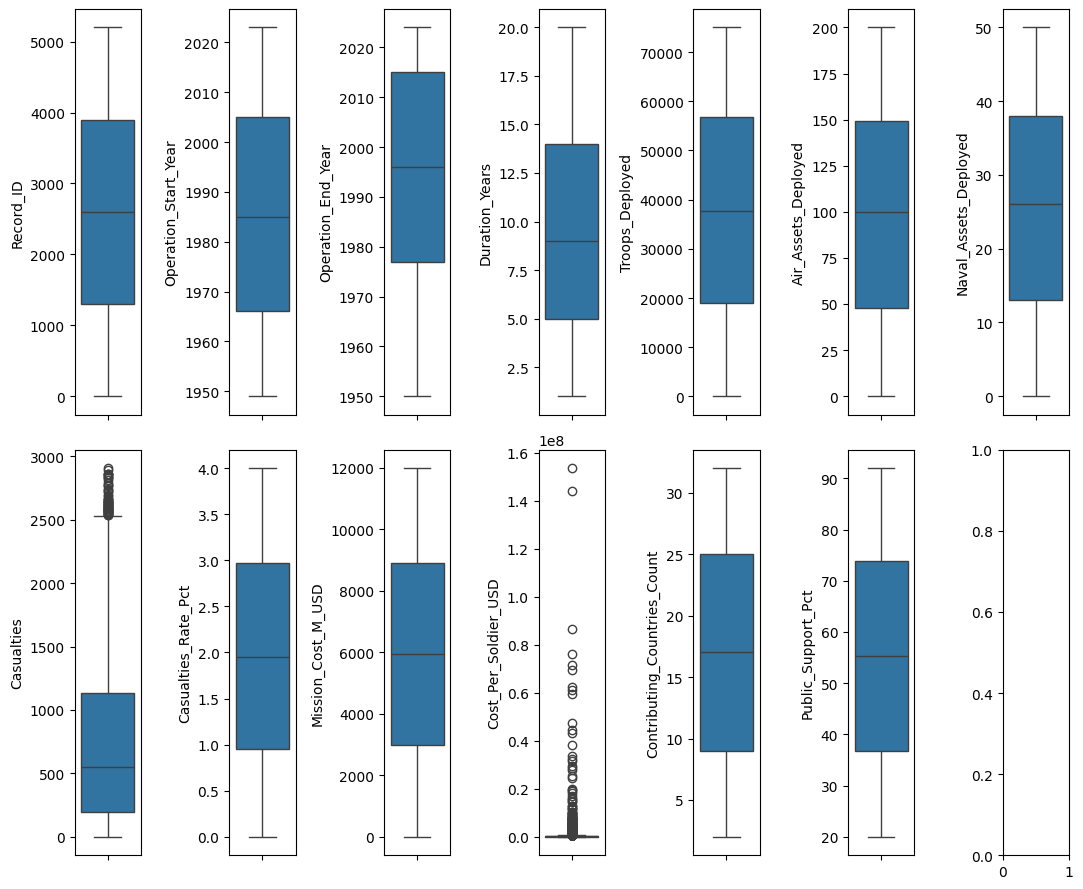

In [54]:

plt.rcParams['figure.figsize'] = [11.00, 9.00]
plt.rcParams['figure.autolayout'] = True

# Com este comando iremos exibir todos gráficos de todas colunas de uma vez só para facilitar nossa analise.

%matplotlib inline

# Aqui definimos em quantas linhas e colunas queremos exibir os gráficos
f, axes = plt.subplots(2, 7) #5 linhas e 4 colunas

linha = 0
coluna = 0

for i in variaveis_numericas:
    sns.boxplot(data = df, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 7:
        linha += 1
        coluna = 0            

plt.show()


In [55]:
for col in df.columns:
    print(f"Coluna: {col}")
    print(df[col].unique())
    print("-" * 30)

Coluna: Record_ID
[   1    2    3 ... 5198 5199 5200]
------------------------------
Coluna: Mission_Name
['Operation Eagle Eye 00001' 'Operation Loyal Leda 00002'
 'Operation Glacier Watch 00003' ... 'Operation Trident Juncture 05198'
 'Operation Viking 05199' 'Operation Thunder Wolf 05200']
------------------------------
Coluna: Mission_Type
['Logistics Support' 'Cyber Defense' 'Combat' 'CBRN Response'
 'Search and Rescue' 'Reconnaissance' 'Intelligence Gathering'
 'Air Policing' 'Training Exercise' 'Maritime Security' 'Disaster Relief'
 'Peacekeeping' 'Ballistic Missile Defense' 'Counter-Terrorism'
 'Naval Patrol' 'Amphibious Exercise' 'Humanitarian Aid'
 'Special Operations']
------------------------------
Coluna: Lead_Country
['Poland' 'Finland' 'Lithuania' 'United Kingdom' 'Portugal' 'Romania'
 'Slovenia' 'France' 'Belgium' 'North Macedonia' 'Türkiye' 'Italy'
 'Bulgaria' 'Croatia' 'Albania' 'Netherlands' 'Spain' 'Luxembourg'
 'Hungary' 'Montenegro' 'Latvia' 'Canada' 'Sweden' 'Cze

In [56]:
#sns.pairplot(df[variaveis_numericas], 
  #          kind='scatter', 
  #          plot_kws={'alpha':0.4}, 
    #        diag_kws={'alpha':0.55, 'bins':40})



# Distribuição de baixas

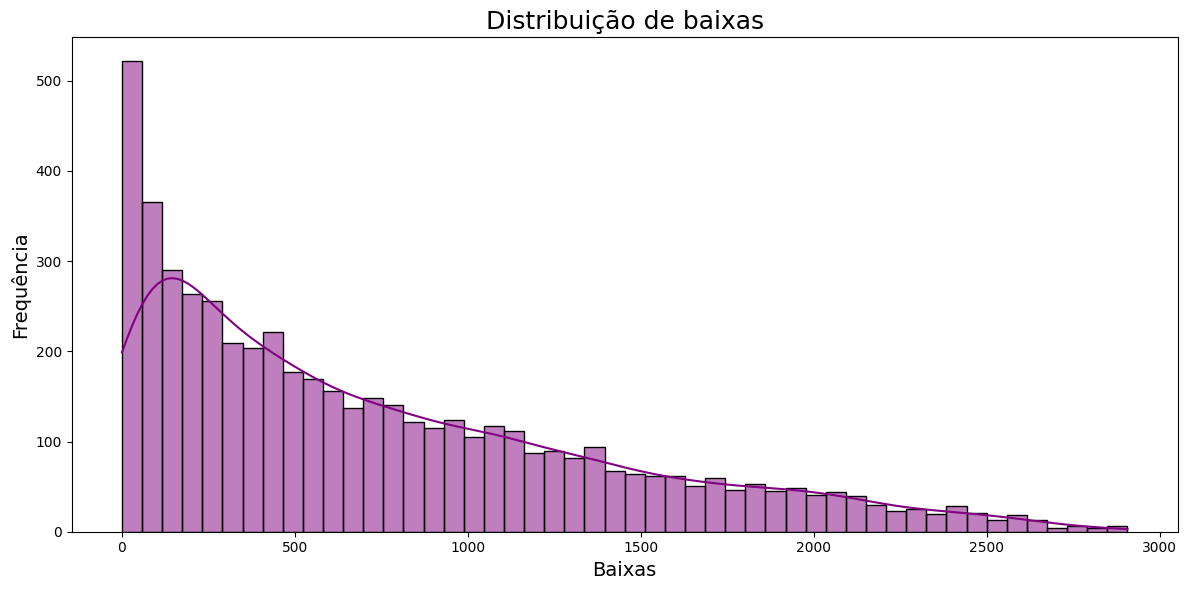

In [57]:
# ============================================================
# 1. Casualties DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Casualties'],
    bins=50,
    kde=True,
    color='purple'
)

plt.title("Distribuição de baixas", fontsize=18)
plt.xlabel("Baixas", fontsize=14)
plt.ylabel("Frequência", fontsize=14)

plt.show()


In [58]:
df.columns

Index(['Record_ID', 'Mission_Name', 'Mission_Type', 'Lead_Country',
       'Lead_ISO_Code', 'Lead_Country_Region', 'Operation_Location',
       'Operation_Region', 'Threat_Level', 'Command_HQ',
       'Operation_Start_Year', 'Operation_End_Year', 'Duration_Years',
       'Mission_Phase', 'Troops_Deployed', 'Air_Assets_Deployed',
       'Naval_Assets_Deployed', 'Casualties', 'Casualties_Rate_Pct',
       'Mission_Cost_M_USD', 'Cost_Per_Soldier_USD',
       'Contributing_Countries_Count', 'NATO_Led', 'UN_Mandate',
       'Mission_Outcome', 'Mission_Status', 'Classification', 'Media_Coverage',
       'Public_Support_Pct', 'After_Action_Report'],
      dtype='object')

# Custo por soldado (USD)

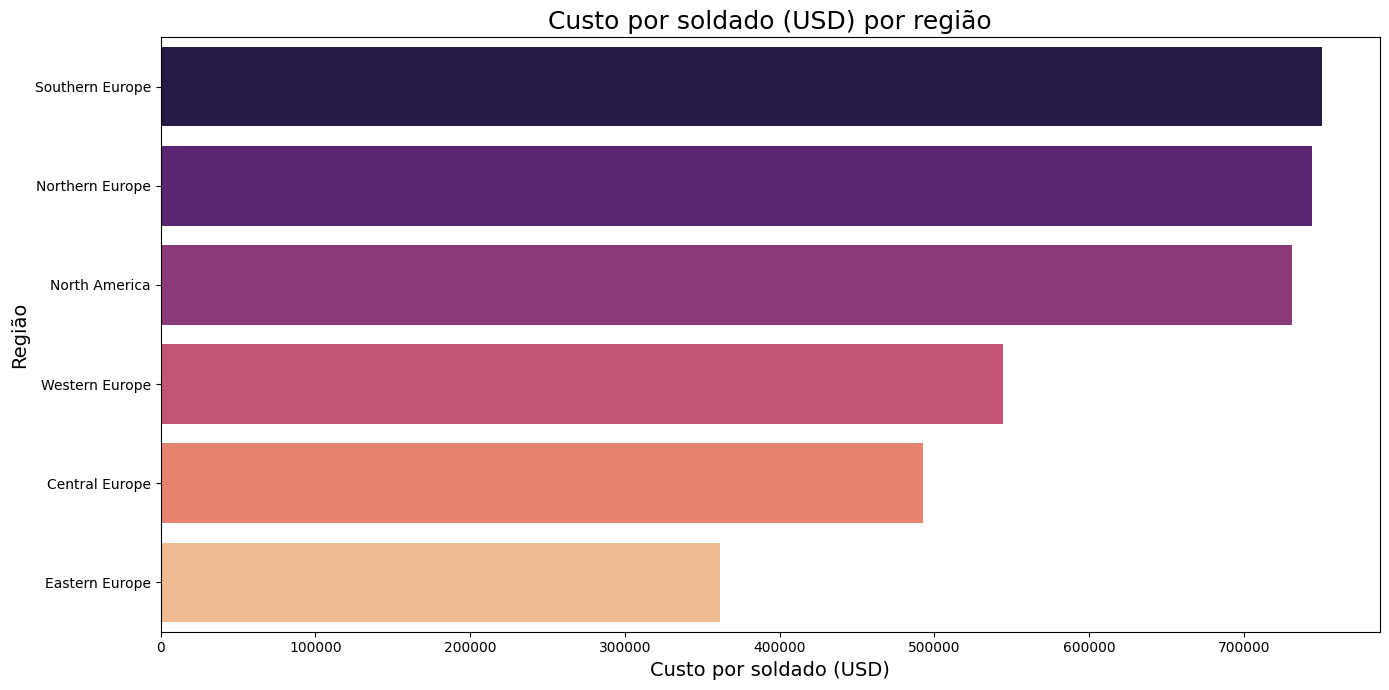

In [59]:
# ============================================================
# 2.   Cost_Per_Soldier_USD'
# ============================================================

top_cards = (
    df.groupby('Lead_Country_Region')['Cost_Per_Soldier_USD']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_cards.values,
    y=top_cards.index,
    hue=top_cards.index,
    palette='magma',
    legend=False
)

plt.title("Custo por soldado (USD) por região", fontsize=18)
plt.xlabel("Custo por soldado (USD)", fontsize=14)
plt.ylabel("Região", fontsize=14)

plt.show()

# Distribuição por país com mais baixas

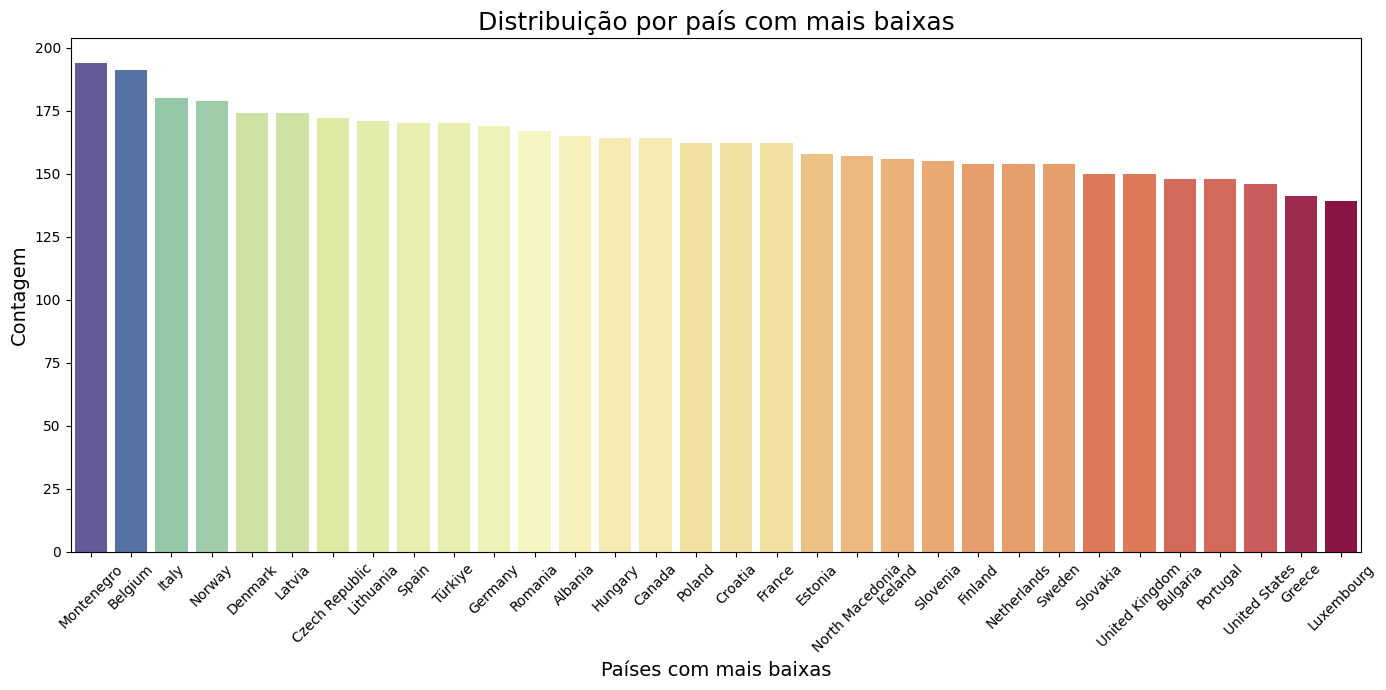

In [60]:


plt.figure(figsize=(14,7))

rarity_counts = df['Lead_Country'].value_counts()

sns.barplot(
    x=rarity_counts.index,
    y=rarity_counts.values,
    hue=rarity_counts.values,
    palette='Spectral',
    legend=False
)

plt.title("Distribuição por país com mais baixas", fontsize=18)
plt.xlabel("Países com mais baixas", fontsize=14)
plt.ylabel("Contagem", fontsize=14)

plt.xticks(rotation=45)

plt.show()


# MAPA DE CALOR DE CORRELAÇÃO

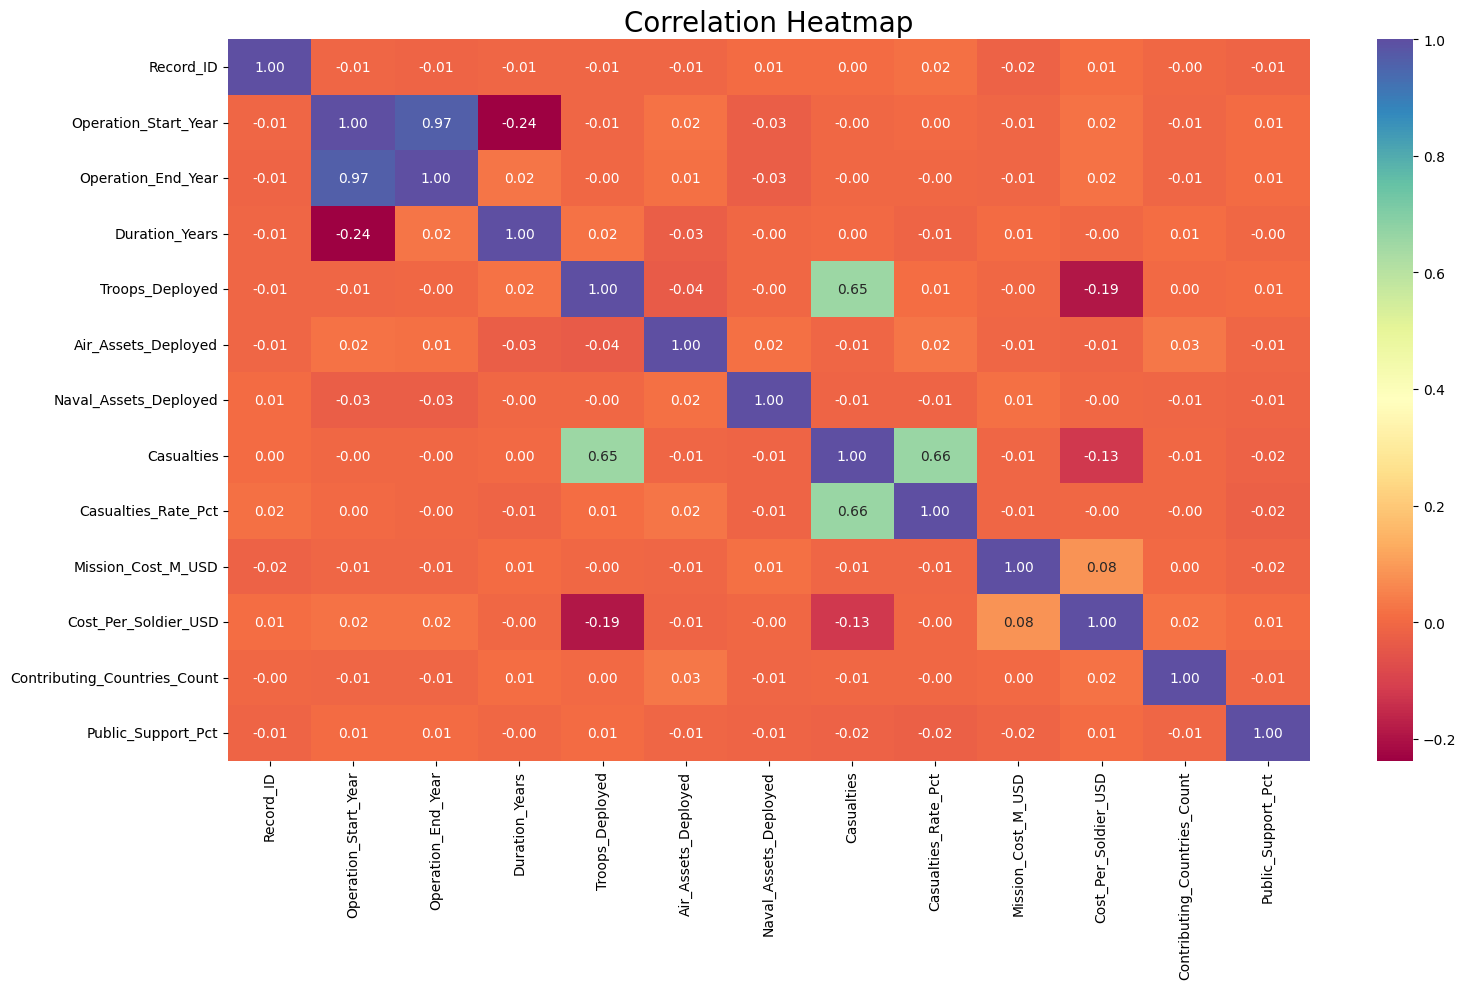

In [61]:
# ============================================================

# ============================================================

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

In [62]:
import sys
!"{sys.executable}" -m pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Treinando modelos para determinar o sucesso das missões

In [63]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Preveremos: Resultado da Missão

In [64]:


target_column = "Mission_Outcome"

print("\n")
print("="*70)
print("TARGET COLUMN")
print("="*70)

print(target_column)

print("\nTarget Value Counts")
print(df[target_column].value_counts())



TARGET COLUMN
Mission_Outcome

Target Value Counts
Mission_Outcome
Inconclusive            605
Withdrawn               599
Suspended               593
Partially Successful    585
Transitioned to UN      573
Mission Accomplished    571
Successful              566
Ongoing                 558
Completed               550
Name: count, dtype: int64


# REMOVENDO AS COLUNAS DE VAZAMENTO DE DADOS

IMPORTANTE: portanto, remova-as para evitar vazamento de dados.

In [65]:


leakage_columns = [
    'Mission_Outcome',
    'Record_ID',
    'Mission_Name',
    'Lead_Country',
    'Lead_Country_Region',
    'Lead_ISO_Code',
    'After_Action_Report'
]

X = df.drop(columns=leakage_columns)



y = df[target_column]

In [66]:


# ============================================================
# LABEL ENCODING TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n")
print("="*70)
print("TARGET LABEL ENCODING")
print("="*70)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")




TARGET LABEL ENCODING
Completed --> 0
Inconclusive --> 1
Mission Accomplished --> 2
Ongoing --> 3
Partially Successful --> 4
Successful --> 5
Suspended --> 6
Transitioned to UN --> 7
Withdrawn --> 8


In [67]:
# ============================================================
# IDENTIFICAR COLUNAS CATEGÓRICAS E NUMÉRICAS
# ============================================================

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("\n")
print("="*70)
print("CATEGORICAL COLUMNS")
print("="*70)

print(categorical_columns, len(categorical_columns))

print("\n")
print("="*70)
print("NUMERICAL COLUMNS")
print("="*70)

print(numerical_columns, len(numerical_columns))




CATEGORICAL COLUMNS
['Mission_Type', 'Operation_Location', 'Operation_Region', 'Threat_Level', 'Command_HQ', 'Mission_Phase', 'NATO_Led', 'UN_Mandate', 'Mission_Status', 'Classification', 'Media_Coverage'] 11


NUMERICAL COLUMNS
['Operation_Start_Year', 'Operation_End_Year', 'Duration_Years', 'Troops_Deployed', 'Air_Assets_Deployed', 'Naval_Assets_Deployed', 'Casualties', 'Casualties_Rate_Pct', 'Mission_Cost_M_USD', 'Cost_Per_Soldier_USD', 'Contributing_Countries_Count', 'Public_Support_Pct'] 12


In [68]:

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

print("\n")
print("="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)



TRAIN TEST SPLIT
X_train Shape : (3900, 23)
X_test Shape  : (1300, 23)
y_train Shape : (3900,)
y_test Shape  : (1300,)


In [69]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Pipelines
preprocessor = ColumnTransformer(transformers=[

    ('num', numerical_transformer, numerical_columns),

    ('cat', categorical_transformer, categorical_columns)

])


In [70]:
# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight='balanced'),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True,
        random_state=42,
        class_weight='balanced'
    )
}


In [71]:

# ============================================================
# STORE RESULTS
# ============================================================

results = []




LOGISTIC REGRESSION

Accuracy Score : 0.1115


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.11      0.11      0.11       137
           1       0.12      0.14      0.13       151
           2       0.12      0.09      0.10       143
           3       0.15      0.12      0.13       140
           4       0.14      0.14      0.14       146
           5       0.05      0.06      0.05       142
           6       0.09      0.10      0.09       148
           7       0.09      0.08      0.08       143
           8       0.13      0.16      0.15       150

    accuracy                           0.11      1300
   macro avg       0.11      0.11      0.11      1300
weighted avg       0.11      0.11      0.11      1300



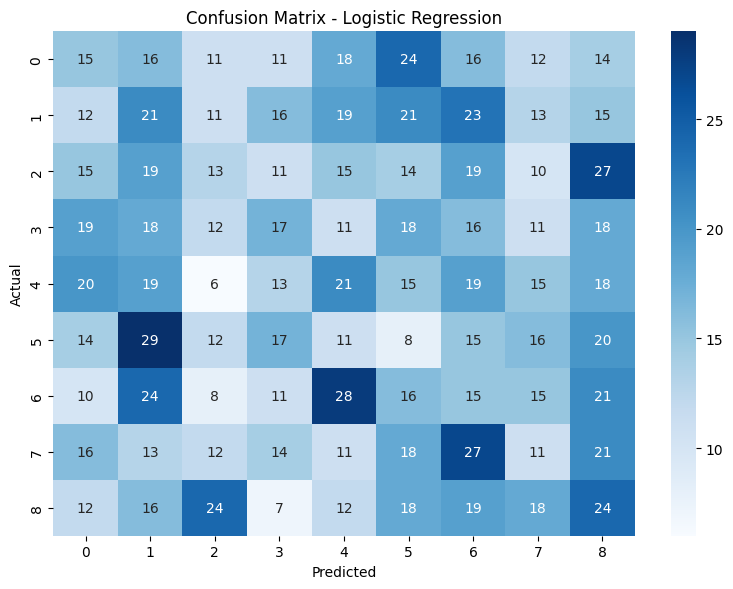


Multi-Class ROC AUC Score : 0.5003


NAIVE BAYES

Accuracy Score : 0.1115


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.09      0.16      0.11       137
           1       0.13      0.15      0.14       151
           2       0.13      0.08      0.10       143
           3       0.13      0.04      0.06       140
           4       0.17      0.10      0.13       146
           5       0.09      0.18      0.12       142
           6       0.08      0.06      0.07       148
           7       0.14      0.16      0.15       143
           8       0.13      0.07      0.09       150

    accuracy                           0.11      1300
   macro avg       0.12      0.11      0.11      1300
weighted avg       0.12      0.11      0.11      1300



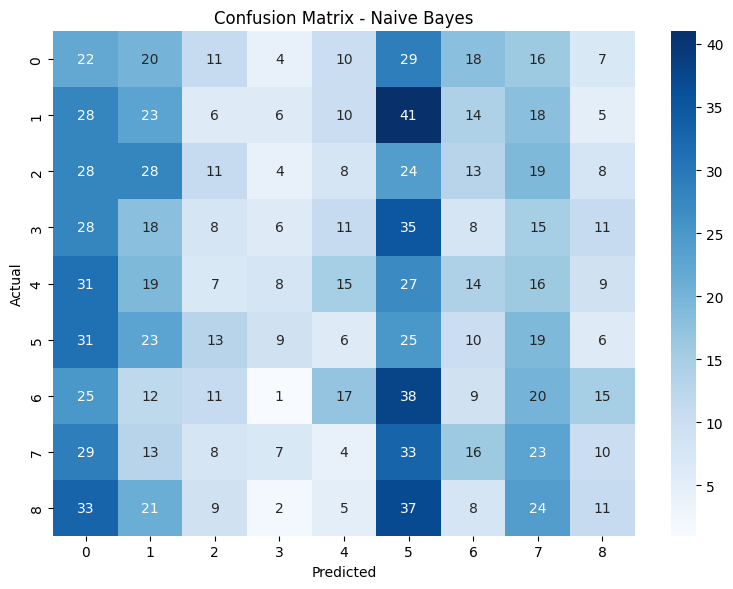


Multi-Class ROC AUC Score : 0.4977


DECISION TREE

Accuracy Score : 0.1015


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.09      0.09      0.09       137
           1       0.10      0.11      0.10       151
           2       0.12      0.13      0.12       143
           3       0.09      0.10      0.10       140
           4       0.13      0.14      0.13       146
           5       0.08      0.07      0.07       142
           6       0.12      0.10      0.11       148
           7       0.07      0.07      0.07       143
           8       0.10      0.11      0.10       150

    accuracy                           0.10      1300
   macro avg       0.10      0.10      0.10      1300
weighted avg       0.10      0.10      0.10      1300



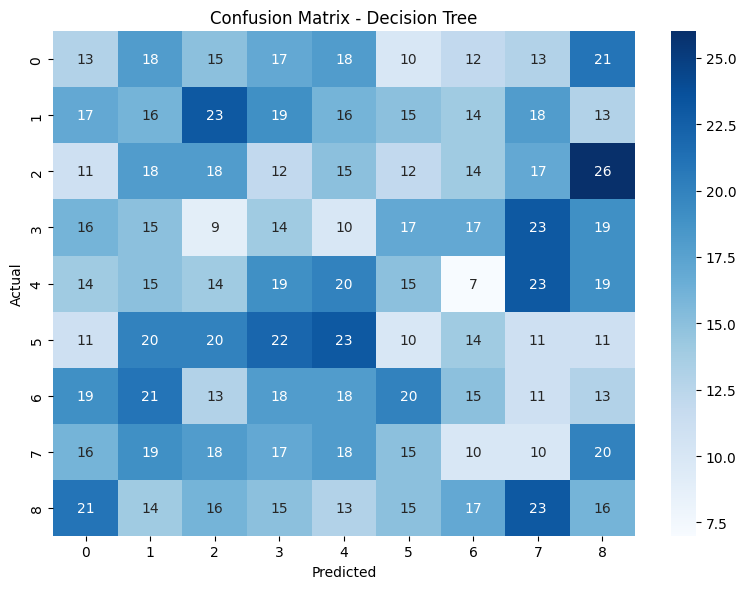


Multi-Class ROC AUC Score : 0.4945


RANDOM FOREST

Accuracy Score : 0.1277


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.10      0.09      0.09       137
           1       0.14      0.20      0.17       151
           2       0.16      0.13      0.14       143
           3       0.09      0.08      0.08       140
           4       0.11      0.12      0.12       146
           5       0.11      0.08      0.09       142
           6       0.14      0.17      0.15       148
           7       0.11      0.09      0.10       143
           8       0.16      0.17      0.17       150

    accuracy                           0.13      1300
   macro avg       0.12      0.13      0.12      1300
weighted avg       0.13      0.13      0.13      1300



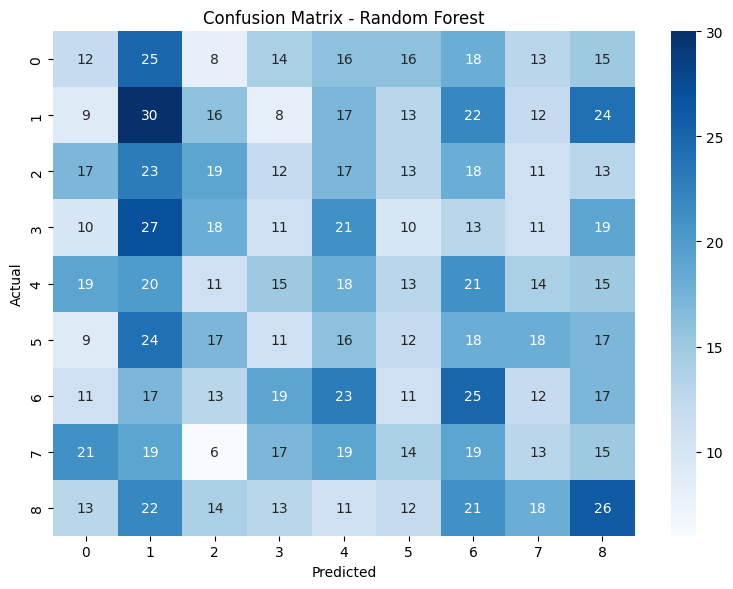


Multi-Class ROC AUC Score : 0.5112


GRADIENT BOOSTING

Accuracy Score : 0.1169


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.10      0.09      0.10       137
           1       0.10      0.13      0.11       151
           2       0.15      0.12      0.13       143
           3       0.15      0.14      0.15       140
           4       0.11      0.10      0.10       146
           5       0.12      0.11      0.12       142
           6       0.11      0.11      0.11       148
           7       0.10      0.10      0.10       143
           8       0.12      0.15      0.13       150

    accuracy                           0.12      1300
   macro avg       0.12      0.12      0.12      1300
weighted avg       0.12      0.12      0.12      1300



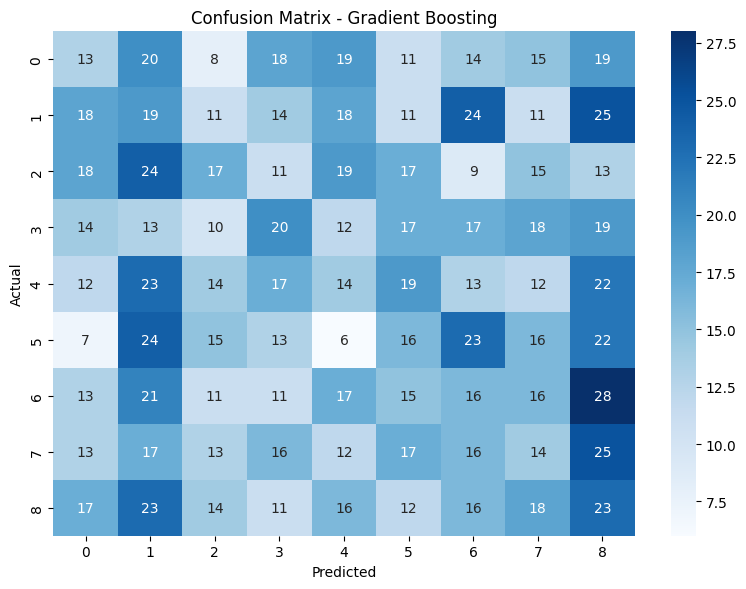


Multi-Class ROC AUC Score : 0.5091


KNN

Accuracy Score : 0.1123


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.10      0.23      0.14       137
           1       0.09      0.13      0.11       151
           2       0.12      0.12      0.12       143
           3       0.12      0.11      0.11       140
           4       0.11      0.09      0.10       146
           5       0.11      0.09      0.10       142
           6       0.11      0.08      0.09       148
           7       0.13      0.08      0.10       143
           8       0.14      0.09      0.11       150

    accuracy                           0.11      1300
   macro avg       0.12      0.11      0.11      1300
weighted avg       0.12      0.11      0.11      1300



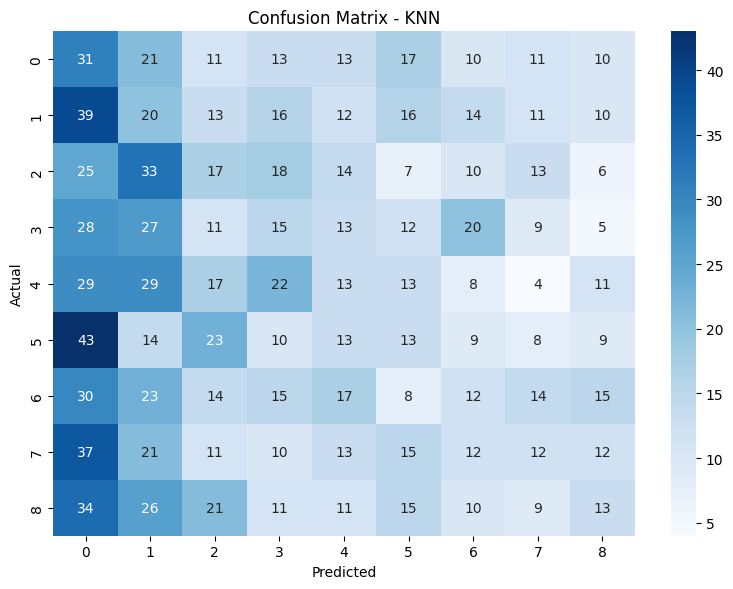


Multi-Class ROC AUC Score : 0.5042


SVM

Accuracy Score : 0.1177


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.12      0.10      0.11       137
           1       0.14      0.24      0.18       151
           2       0.09      0.06      0.07       143
           3       0.09      0.06      0.07       140
           4       0.13      0.15      0.14       146
           5       0.09      0.08      0.08       142
           6       0.12      0.14      0.13       148
           7       0.10      0.08      0.09       143
           8       0.12      0.14      0.13       150

    accuracy                           0.12      1300
   macro avg       0.11      0.12      0.11      1300
weighted avg       0.11      0.12      0.11      1300



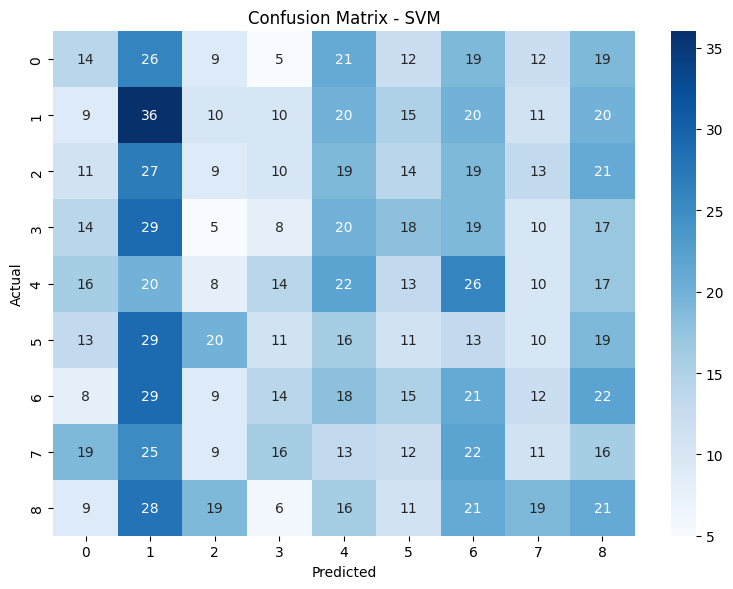


Multi-Class ROC AUC Score : 0.4940


FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
3        Random Forest  0.127692  0.511245
6                  SVM  0.117692  0.494005
4    Gradient Boosting  0.116923  0.509088
5                  KNN  0.112308  0.504246
0  Logistic Regression  0.111538  0.500337
1          Naive Bayes  0.111538  0.497709
2        Decision Tree  0.101538  0.494514


C:\Users\gugaa\AppData\Local\Temp\ipykernel_22420\1373947001.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


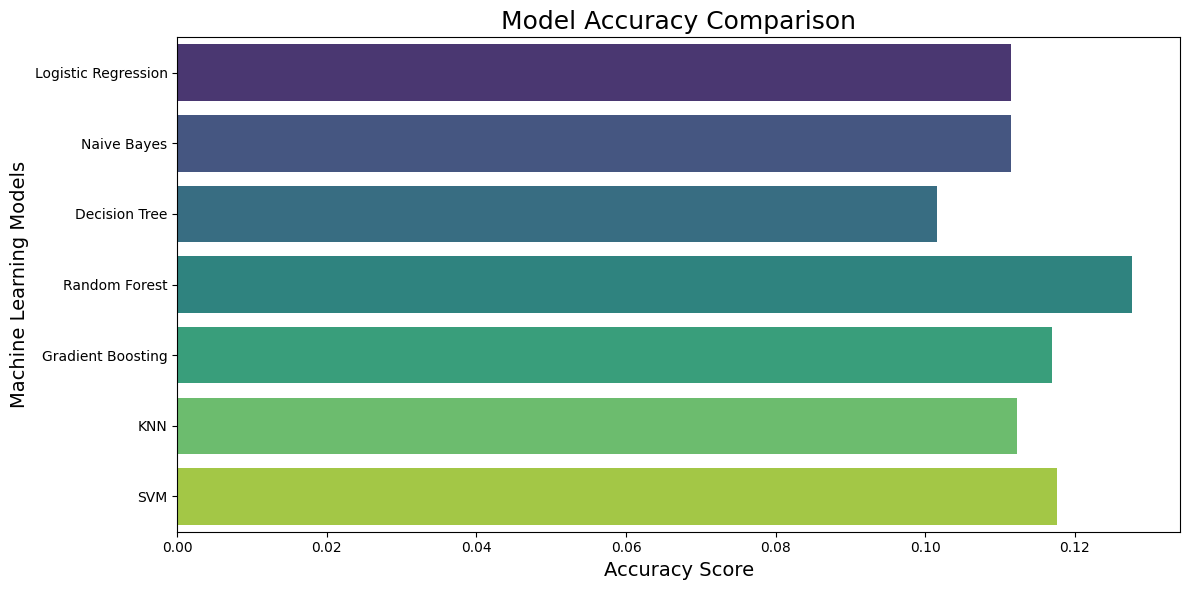

C:\Users\gugaa\AppData\Local\Temp\ipykernel_22420\1373947001.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


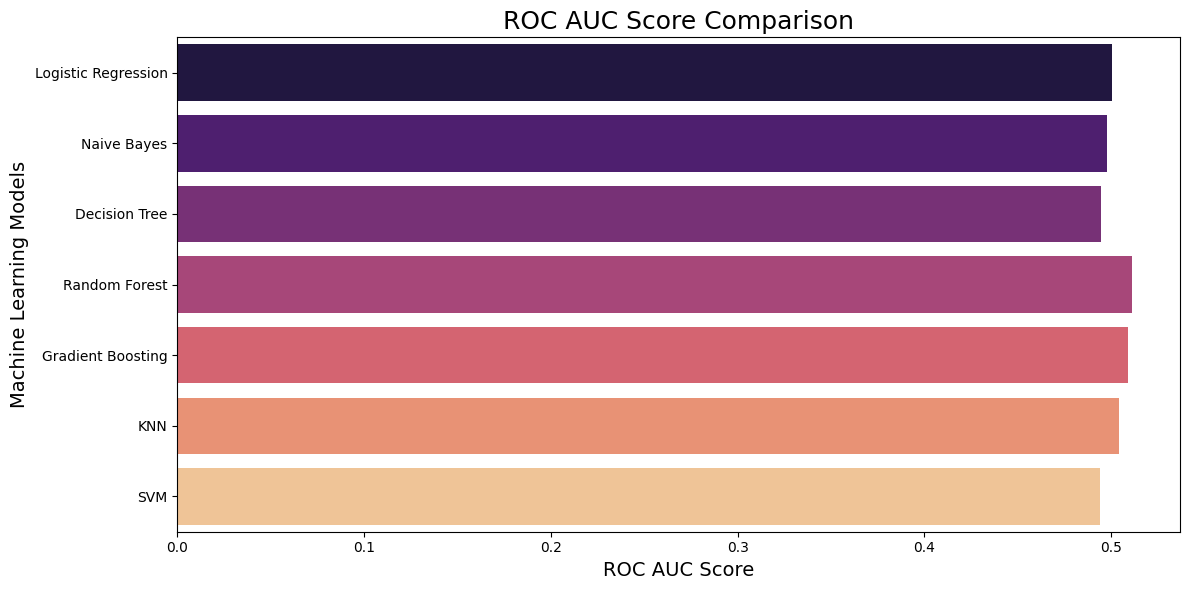



BEST MODEL
Best Model      : Random Forest
Best Accuracy   : 0.1277
Best ROC AUC    : 0.5112


RANDOM FOREST FEATURE IMPORTANCE
                         Feature  Importance
8             Mission_Cost_M_USD    0.047601
7            Casualties_Rate_Pct    0.047313
11            Public_Support_Pct    0.047104
3                Troops_Deployed    0.046882
4            Air_Assets_Deployed    0.046719
9           Cost_Per_Soldier_USD    0.046044
6                     Casualties    0.045929
5          Naval_Assets_Deployed    0.043550
0           Operation_Start_Year    0.042646
10  Contributing_Countries_Count    0.041618
1             Operation_End_Year    0.040562
2                 Duration_Years    0.038519
81                   NATO_Led_No    0.010232
80        NATO_Led_Joint UN-NATO    0.010119
82                  NATO_Led_Yes    0.010094
83                 UN_Mandate_No    0.009728
98         Media_Coverage_Medium    0.009553
84                UN_Mandate_Yes    0.009514
96           Me

C:\Users\gugaa\AppData\Local\Temp\ipykernel_22420\1373947001.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


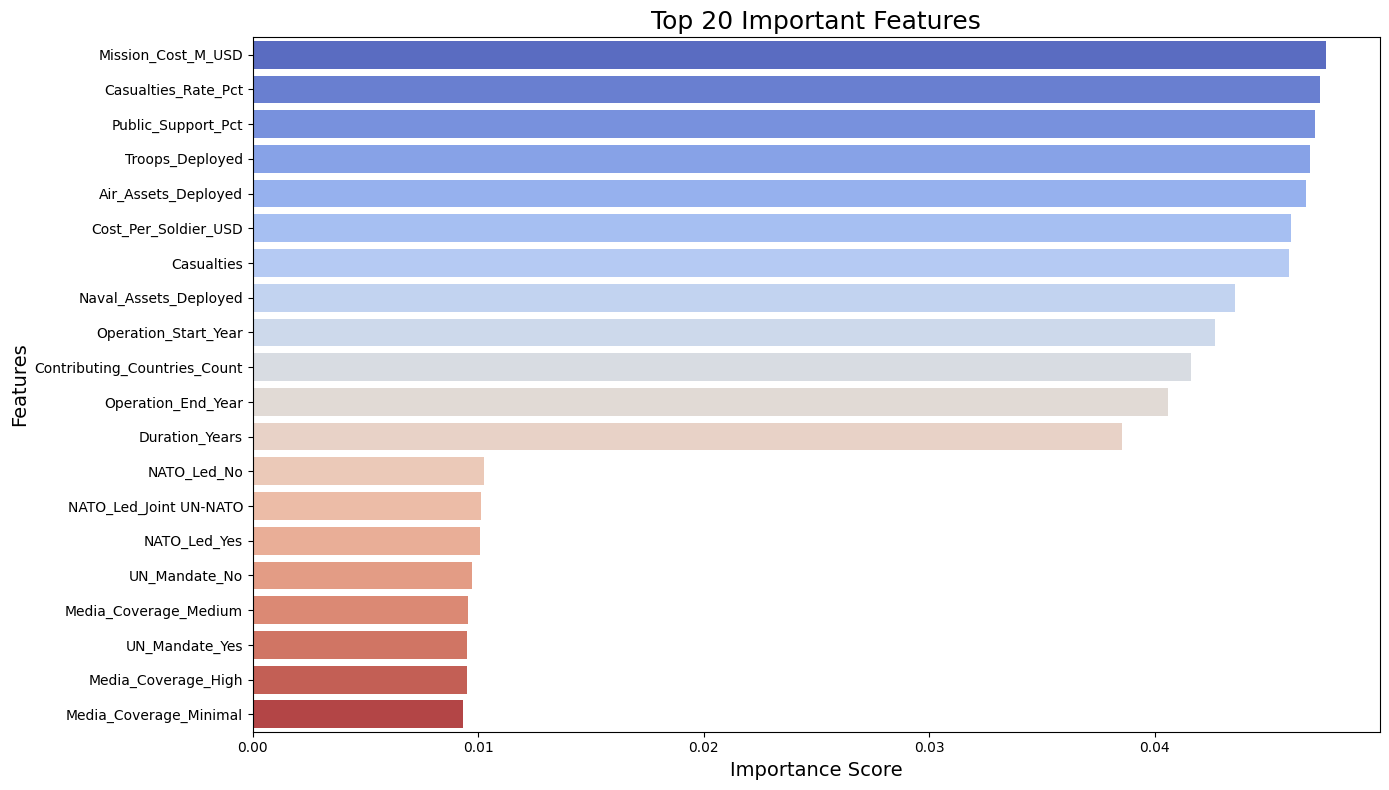



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [72]:
# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(model_name.upper())
    print("="*80)

    # ========================================================
    # SPECIAL HANDLING FOR NAIVE BAYES
    # ========================================================

    if model_name == "Naive Bayes":

        # Transform data first
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # Convert sparse matrix to dense
        X_train_processed = X_train_processed.toarray()
        X_test_processed = X_test_processed.toarray()

        # Fit model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probabilities
        y_prob = model.predict_proba(X_test_processed)

    else:

        # Full pipeline
        pipeline = Pipeline(steps=[

            ('preprocessor', preprocessor),

            ('model', model)

        ])

        # Train model
        pipeline.fit(X_train, y_train)

        # Predictions
        y_pred = pipeline.predict(X_test)

        # Prediction probabilities
        y_prob = pipeline.predict_proba(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\n")
    print("CLASSIFICATION REPORT")
    print("-"*60)

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    # Binary or Multi-class handling

    if len(np.unique(y_encoded)) == 2:

        # Binary Classification ROC
        auc_score = roc_auc_score(y_test, y_prob[:,1])

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob[:,1]
        )

        plt.figure(figsize=(8,6))

        plt.plot(
            fpr,
            tpr,
            linewidth=3,
            label=f'AUC = {auc_score:.4f}'
        )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"ROC Curve - {model_name}")

        plt.legend()

        plt.show()

    else:

        # Multi-class ROC AUC
        auc_score = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )

        print(f"\nMulti-Class ROC AUC Score : {auc_score:.4f}")

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score

    })

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df.sort_values(by='Accuracy', ascending=False))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Accuracy Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# VISUALIZE ROC AUC SCORES
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Score Comparison", fontsize=18)

plt.xlabel("ROC AUC Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model      : {best_model['Model']}")
print(f"Best Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Best ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

print("\n")
print("="*80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*80)

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

rf_pipeline.fit(X_train, y_train)

# Get feature names after encoding
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
].get_feature_names_out(categorical_columns)

all_features = np.concatenate([
    numerical_columns,
    encoded_cat_features
])

# Get importances
importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,
    'Importance': importances

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(feature_importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 20 Important Features", fontsize=18)

plt.xlabel("Importance Score", fontsize=14)

plt.ylabel("Features", fontsize=14)

plt.show()

# ============================================================
# COMPLETED
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
3        Random Forest  0.127692  0.511245
6                  SVM  0.117692  0.494005
7                  SVM  0.117692  0.494005
4    Gradient Boosting  0.116923  0.509088
5                  KNN  0.112308  0.504246
0  Logistic Regression  0.111538  0.500337
1          Naive Bayes  0.111538  0.497709
2        Decision Tree  0.101538  0.494514


C:\Users\gugaa\AppData\Local\Temp\ipykernel_22420\3518930434.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


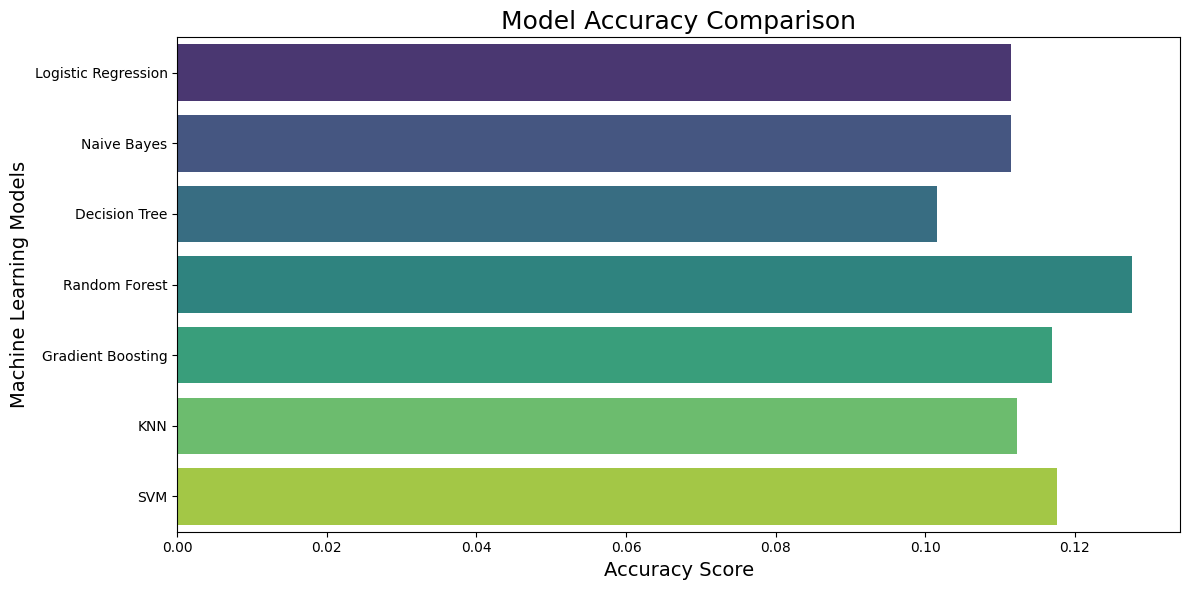

C:\Users\gugaa\AppData\Local\Temp\ipykernel_22420\3518930434.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


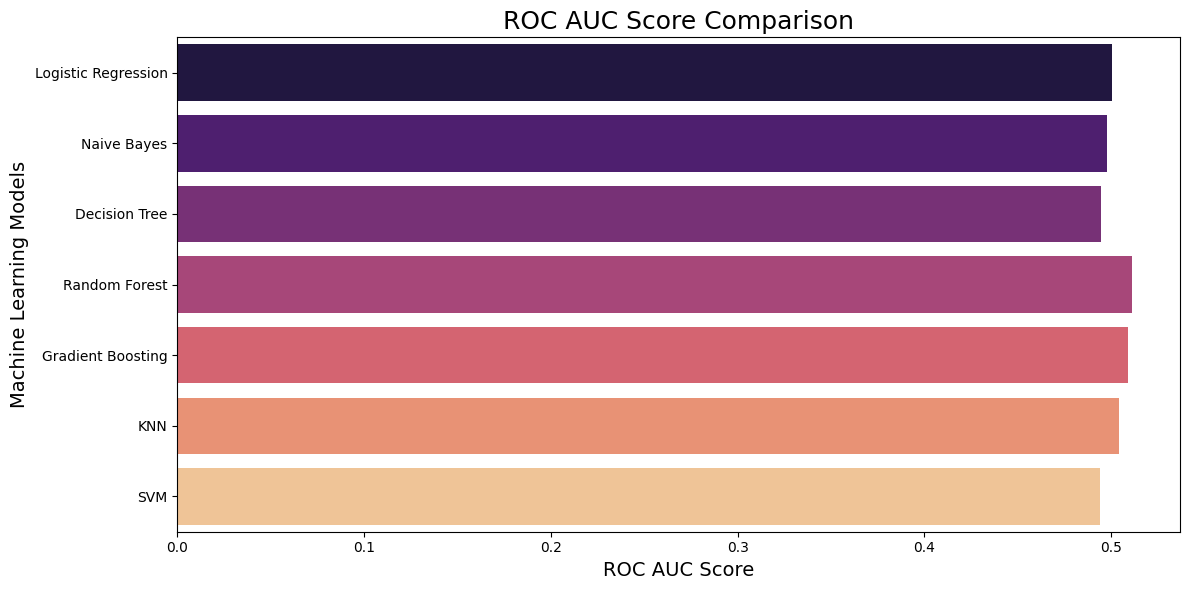



BEST MODEL
Best Model      : Random Forest
Best Accuracy   : 0.1277
Best ROC AUC    : 0.5112


RANDOM FOREST FEATURE IMPORTANCE
                         Feature  Importance
8             Mission_Cost_M_USD    0.047601
7            Casualties_Rate_Pct    0.047313
11            Public_Support_Pct    0.047104
3                Troops_Deployed    0.046882
4            Air_Assets_Deployed    0.046719
9           Cost_Per_Soldier_USD    0.046044
6                     Casualties    0.045929
5          Naval_Assets_Deployed    0.043550
0           Operation_Start_Year    0.042646
10  Contributing_Countries_Count    0.041618
1             Operation_End_Year    0.040562
2                 Duration_Years    0.038519
81                   NATO_Led_No    0.010232
80        NATO_Led_Joint UN-NATO    0.010119
82                  NATO_Led_Yes    0.010094
83                 UN_Mandate_No    0.009728
98         Media_Coverage_Medium    0.009553
84                UN_Mandate_Yes    0.009514
96           Me

C:\Users\gugaa\AppData\Local\Temp\ipykernel_22420\3518930434.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


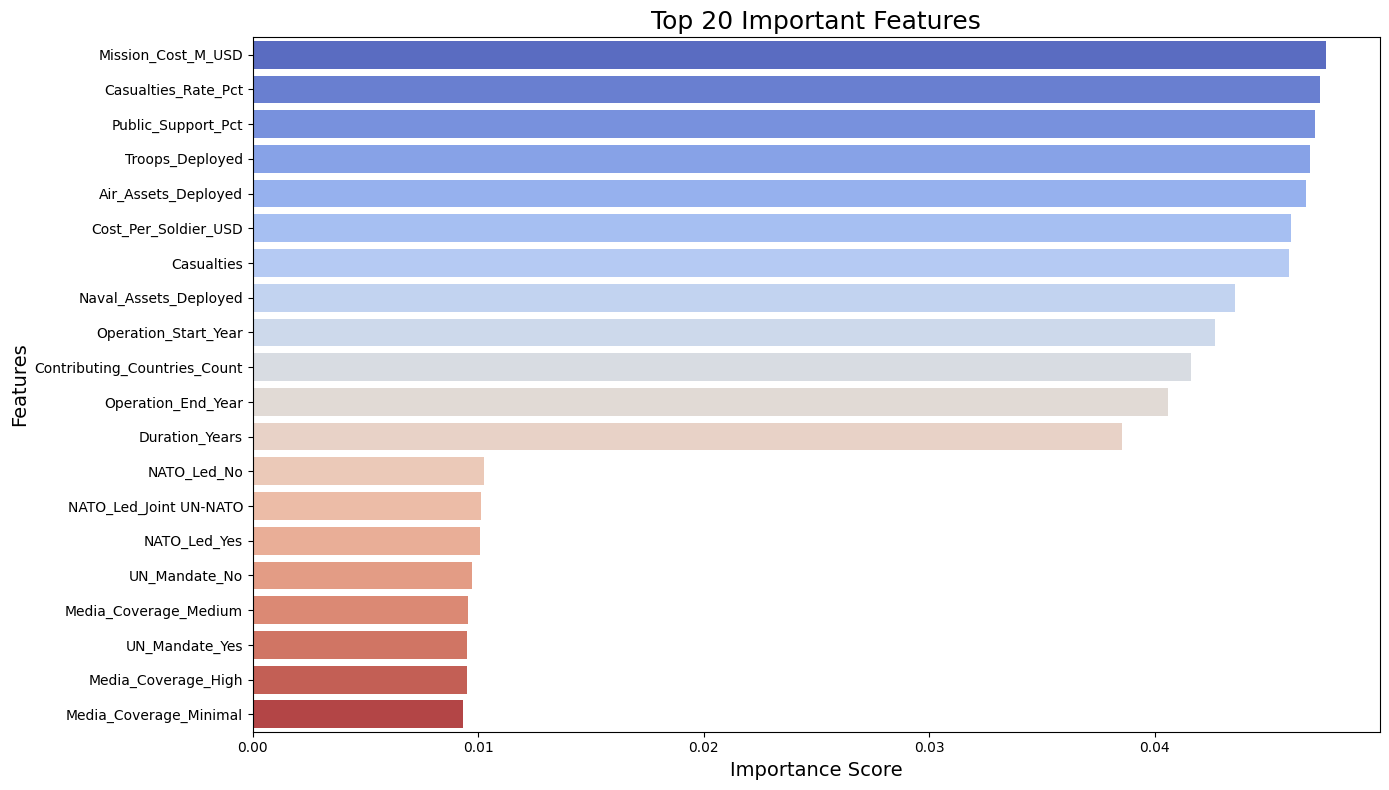



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [73]:

# ========================================================
# STORE RESULTS
# ========================================================

results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score

    })

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df.sort_values(by='Accuracy', ascending=False))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Accuracy Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# VISUALIZE ROC AUC SCORES
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Score Comparison", fontsize=18)

plt.xlabel("ROC AUC Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model      : {best_model['Model']}")
print(f"Best Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Best ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

print("\n")
print("="*80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*80)

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

rf_pipeline.fit(X_train, y_train)

# Get feature names after encoding
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
].get_feature_names_out(categorical_columns)

all_features = np.concatenate([
    numerical_columns,
    encoded_cat_features
])

# Get importances
importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,
    'Importance': importances

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(feature_importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 20 Important Features", fontsize=18)

plt.xlabel("Importance Score", fontsize=14)

plt.ylabel("Features", fontsize=14)

plt.show()

# ============================================================
# COMPLETED
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

# Colapsando para Sucesso / Fracasso (binário)

Mapeamento adotado (ajuste se quiser um critério diferente):

- **Sucesso (1):** Successful, Mission Accomplished, Completed, Transitioned to UN
- **Fracasso (0):** Partially Successful, Withdrawn, Suspended, Inconclusive
- **Removido do dataset:** Ongoing — a missão ainda não terminou, então não tem um outcome resolvido pra classificar.

`Partially Successful` foi tratado como fracasso porque, por definição, não atingiu o objetivo completo. `Transitioned to UN` foi tratado como sucesso porque é um handover planejado, não um encerramento forçado. Isso é uma escolha de critério — se você quiser um corte mais rígido (só `Successful` + `Mission Accomplished` como sucesso), é só editar o dicionário abaixo.


In [74]:
# ============================================================
# CRIANDO TARGET BINÁRIO
# ============================================================

# Dicionário que traduz cada uma das 9 categorias originais em 1 (sucesso),
# 0 (fracasso) ou None (descarta a linha, usado só para 'Ongoing')
outcome_map = {
    'Successful': 1,             # sucesso declarado
    'Mission Accomplished': 1,   # sucesso declarado
    'Completed': 1,               # encerrou conforme planejado -> sucesso
    'Transitioned to UN': 1,     # handover planejado -> tratado como sucesso

    'Partially Successful': 0,   # não atingiu o objetivo completo -> fracasso
    'Withdrawn': 0,               # encerramento forçado -> fracasso
    'Suspended': 0,               # missão interrompida -> fracasso
    'Inconclusive': 0,           # não se resolveu de forma clara -> fracasso

    'Ongoing': None,             # missão ainda não terminou -> sem outcome, remover
}

# Aplica o mapeamento na coluna original, criando uma nova coluna numérica
df['Mission_Success'] = df['Mission_Outcome'].map(outcome_map)

# Mantém só as linhas onde o mapeamento não deu None (ou seja, remove 'Ongoing')
# .copy() evita o SettingWithCopyWarning nas linhas seguintes
df_bin = df[df['Mission_Success'].notna()].copy()

# Mission_Success veio como float (por causa do None/NaN) -> converte para int
df_bin['Mission_Success'] = df_bin['Mission_Success'].astype(int)

# Quantas linhas foram descartadas (deveriam ser as 558 'Ongoing')
print("Linhas removidas (Ongoing):", df['Mission_Success'].isna().sum())

# Quantas linhas sobraram pro treino/teste
print("Linhas restantes:", len(df_bin))
print()

# Checa se as duas classes ficaram balanceadas (importante pra decidir
# se precisa de class_weight='balanced' nos modelos)
print("Balanceamento de classes:")
print(df_bin['Mission_Success'].value_counts())
print(df_bin['Mission_Success'].value_counts(normalize=True).round(3))


Linhas removidas (Ongoing): 558
Linhas restantes: 4642

Balanceamento de classes:
Mission_Success
0    2382
1    2260
Name: count, dtype: int64
Mission_Success
0    0.513
1    0.487
Name: proportion, dtype: float64


In [75]:
# ============================================================
# X / y BINÁRIOS (reaplicando as mesmas colunas de vazamento)
# ============================================================

# Reaproveita a lista de colunas de vazamento já usada no problema de 9 classes
# e adiciona 'Mission_Success', que também não pode entrar como feature
# (senão o modelo estaria "vendo" o próprio target)
leakage_columns_bin = leakage_columns + ['Mission_Success']

# Remove as colunas de vazamento do dataframe binário -> sobram só as features
X_bin = df_bin.drop(columns=leakage_columns_bin)

# Isola a coluna alvo (0 = fracasso, 1 = sucesso)
y_bin = df_bin['Mission_Success']

# Recalcula quais colunas são categóricas (texto) neste novo X_bin
categorical_columns_bin = X_bin.select_dtypes(include=['object']).columns.tolist()

# Recalcula quais colunas são numéricas neste novo X_bin
numerical_columns_bin = X_bin.select_dtypes(include=np.number).columns.tolist()

# Separa treino/teste; stratify=y_bin garante que a proporção sucesso/fracasso
# seja mantida tanto no treino quanto no teste
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin,
    y_bin,
    test_size=0.25,     # 25% dos dados vão pro teste
    random_state=42,    # garante que o split é sempre o mesmo ao re-executar
    stratify=y_bin       # mantém a proporção de classes igual no treino e no teste
)

# Confere o tamanho de cada pedaço do split
print("X_train_bin Shape :", X_train_bin.shape)
print("X_test_bin Shape  :", X_test_bin.shape)


X_train_bin Shape : (3481, 23)
X_test_bin Shape  : (1161, 23)



LOGISTIC REGRESSION

Accuracy Score : 0.5073
ROC AUC Score  : 0.5000

              precision    recall  f1-score   support

           0       0.52      0.56      0.54       596
           1       0.49      0.45      0.47       565

    accuracy                           0.51      1161
   macro avg       0.51      0.51      0.51      1161
weighted avg       0.51      0.51      0.51      1161



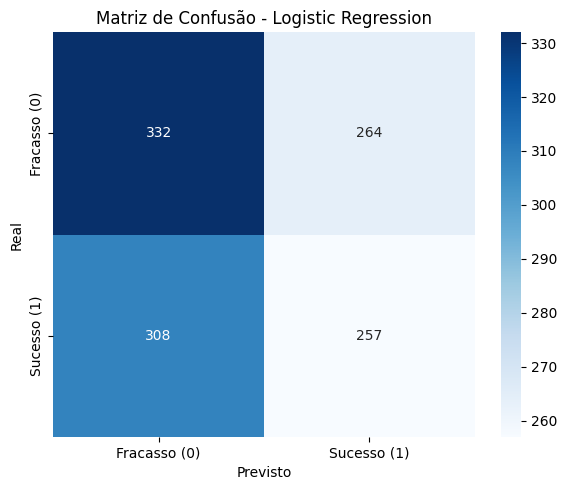

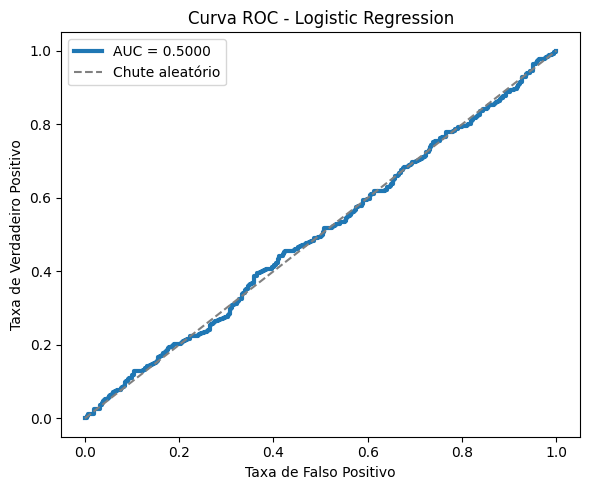


NAIVE BAYES

Accuracy Score : 0.4987
ROC AUC Score  : 0.5033

              precision    recall  f1-score   support

           0       0.52      0.38      0.44       596
           1       0.49      0.62      0.55       565

    accuracy                           0.50      1161
   macro avg       0.50      0.50      0.49      1161
weighted avg       0.50      0.50      0.49      1161



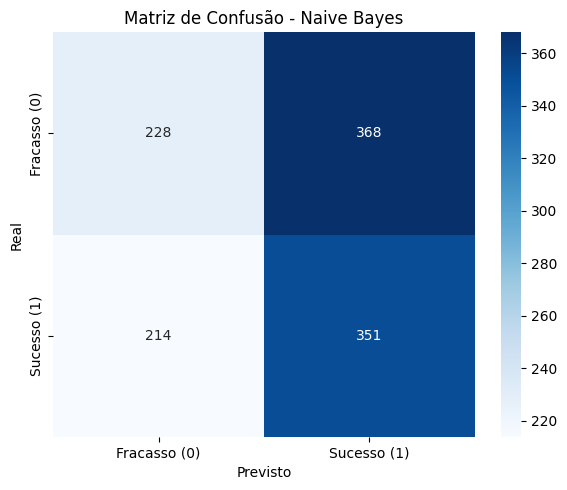

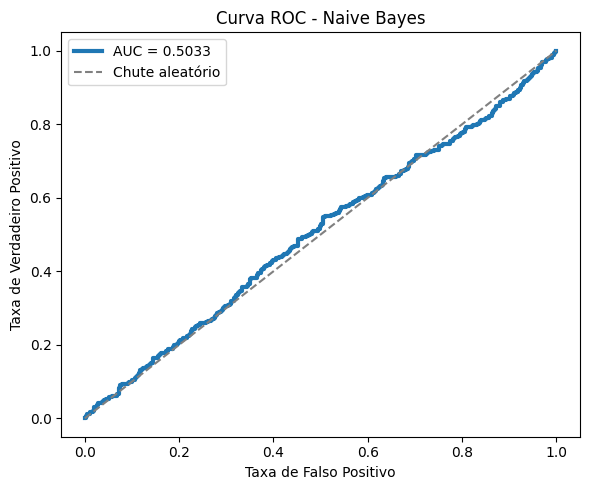


DECISION TREE

Accuracy Score : 0.5168
ROC AUC Score  : 0.5167

              precision    recall  f1-score   support

           0       0.53      0.52      0.52       596
           1       0.50      0.51      0.51       565

    accuracy                           0.52      1161
   macro avg       0.52      0.52      0.52      1161
weighted avg       0.52      0.52      0.52      1161



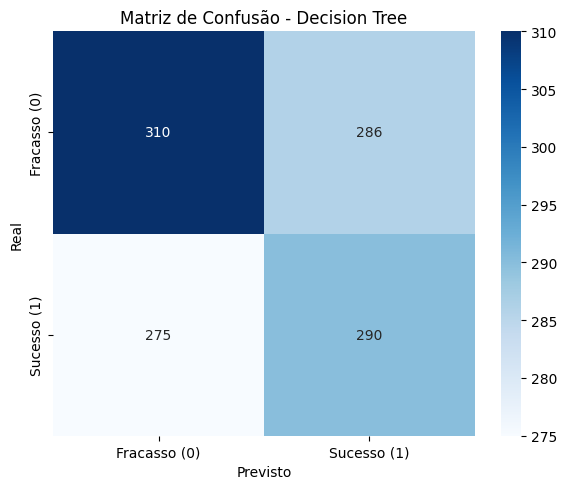

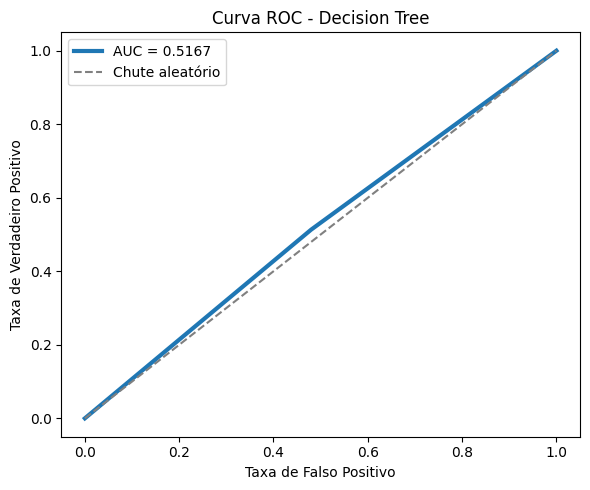


RANDOM FOREST

Accuracy Score : 0.5202
ROC AUC Score  : 0.5172

              precision    recall  f1-score   support

           0       0.53      0.62      0.57       596
           1       0.51      0.41      0.46       565

    accuracy                           0.52      1161
   macro avg       0.52      0.52      0.51      1161
weighted avg       0.52      0.52      0.52      1161



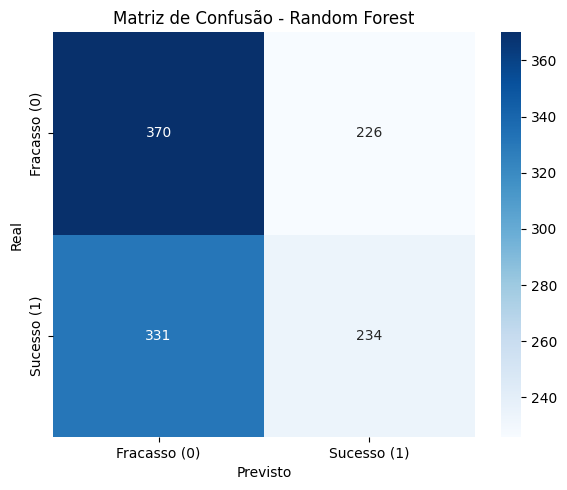

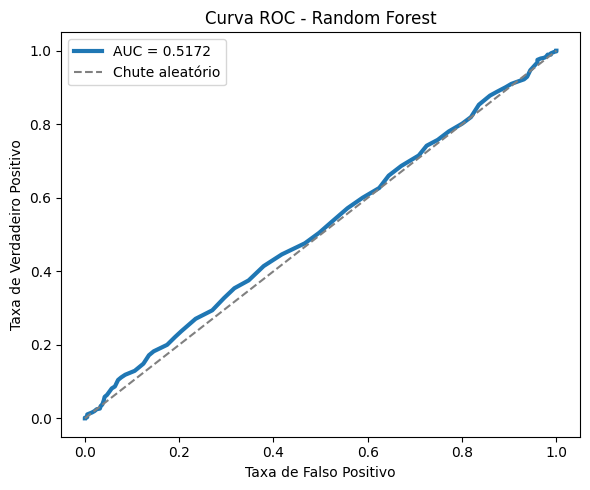


GRADIENT BOOSTING

Accuracy Score : 0.4996
ROC AUC Score  : 0.5199

              precision    recall  f1-score   support

           0       0.51      0.59      0.55       596
           1       0.48      0.41      0.44       565

    accuracy                           0.50      1161
   macro avg       0.50      0.50      0.49      1161
weighted avg       0.50      0.50      0.50      1161



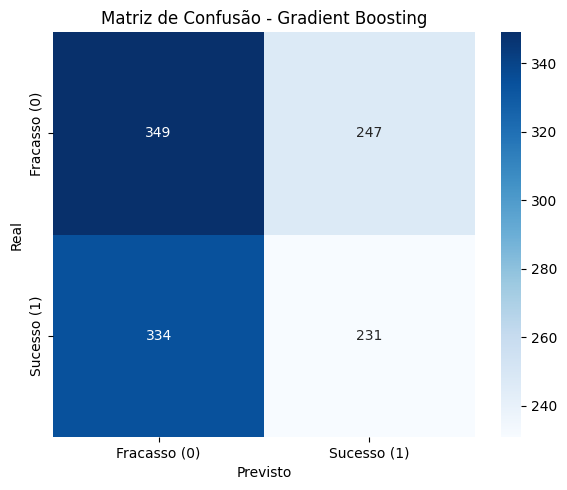

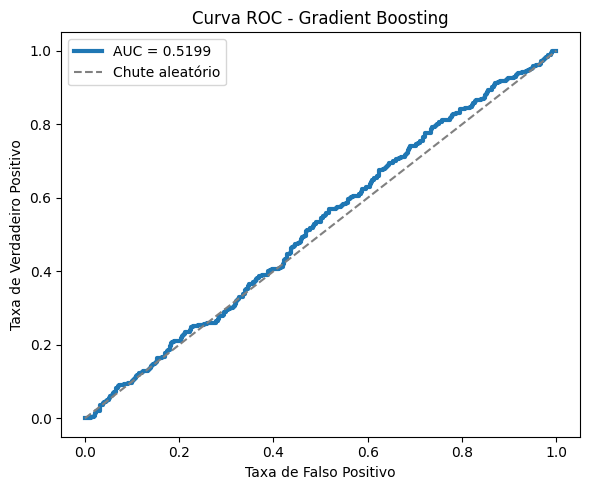


KNN

Accuracy Score : 0.5108
ROC AUC Score  : 0.5134

              precision    recall  f1-score   support

           0       0.52      0.53      0.53       596
           1       0.50      0.49      0.49       565

    accuracy                           0.51      1161
   macro avg       0.51      0.51      0.51      1161
weighted avg       0.51      0.51      0.51      1161



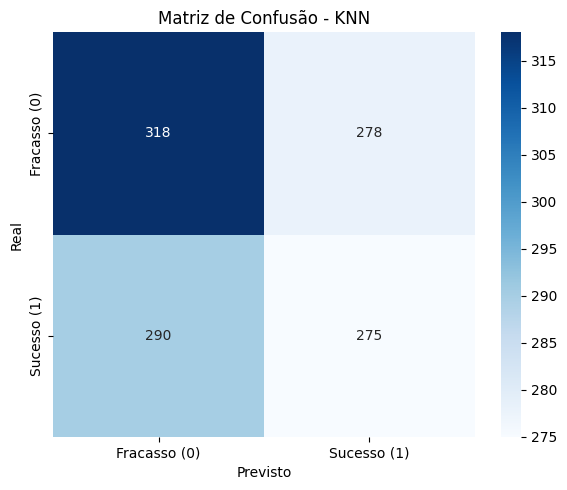

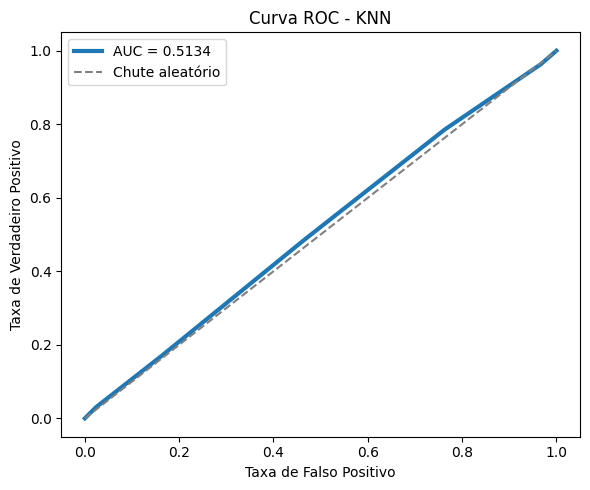


SVM

Accuracy Score : 0.5220
ROC AUC Score  : 0.5201

              precision    recall  f1-score   support

           0       0.53      0.60      0.56       596
           1       0.51      0.44      0.47       565

    accuracy                           0.52      1161
   macro avg       0.52      0.52      0.52      1161
weighted avg       0.52      0.52      0.52      1161



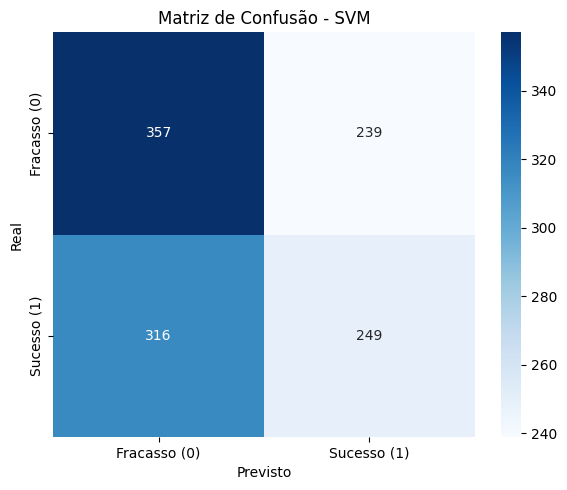

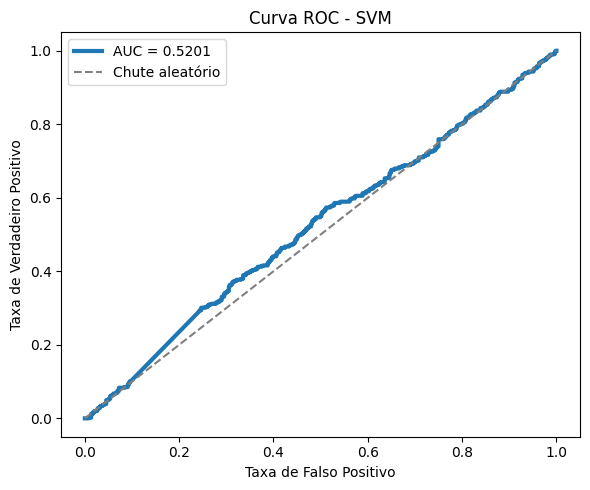


COMPARAÇÃO FINAL - TARGET BINÁRIO
                 Model  Accuracy   ROC_AUC
6                  SVM  0.521964  0.520072
4    Gradient Boosting  0.499569  0.519879
3        Random Forest  0.520241  0.517178
2        Decision Tree  0.516796  0.516704
5                  KNN  0.510767  0.513392
1          Naive Bayes  0.498708  0.503255
0  Logistic Regression  0.507321  0.500024


In [76]:
# ============================================================
# PIPELINE + MODELOS (mesma estrutura de antes, aplicada ao target binário)
# ============================================================

# Pipeline de pré-processamento só pra colunas numéricas:
numerical_transformer_bin = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # preenche NaN com a mediana da coluna
    ('scaler', StandardScaler())                     # padroniza (média 0, desvio 1)
])

# Pipeline de pré-processamento só pra colunas categóricas:
categorical_transformer_bin = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # preenche NaN com a categoria mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # transforma texto em colunas 0/1
])

# Junta os dois pipelines acima, cada um aplicado ao seu grupo de colunas
preprocessor_bin = ColumnTransformer(transformers=[
    ('num', numerical_transformer_bin, numerical_columns_bin),
    ('cat', categorical_transformer_bin, categorical_columns_bin)
])

# Dicionário com os modelos que vamos comparar (sem class_weight, já que
# as classes ficaram ~49%/51%, quase balanceadas)
models_bin = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

# Lista onde vamos guardar accuracy e AUC de cada modelo, pra comparar no final
results_bin = []

# Loop: treina cada modelo, avalia, plota matriz de confusão + curva ROC, guarda o resultado
for model_name, model in models_bin.items():

    print("\n" + "="*80)
    print(model_name.upper())
    print("="*80)

    if model_name == "Naive Bayes":
        # GaussianNB não aceita matriz esparsa -> precisa converter pra densa
        # (por isso ele é tratado fora do Pipeline, separado dos outros)
        X_train_proc = preprocessor_bin.fit_transform(X_train_bin).toarray()
        X_test_proc = preprocessor_bin.transform(X_test_bin).toarray()
        model.fit(X_train_proc, y_train_bin)          # treina o modelo
        y_pred = model.predict(X_test_proc)             # classe prevista (0 ou 1)
        y_prob = model.predict_proba(X_test_proc)        # probabilidade de cada classe
    else:
        # Para os demais modelos, o Pipeline já cuida do pré-processamento
        # + treino em um único objeto, evitando vazamento entre train/test
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor_bin),
            ('model', model)
        ])
        pipeline.fit(X_train_bin, y_train_bin)           # treina preprocessador + modelo
        y_pred = pipeline.predict(X_test_bin)             # classe prevista
        y_prob = pipeline.predict_proba(X_test_bin)        # probabilidade de cada classe

    # Proporção de acertos no conjunto de teste
    accuracy = accuracy_score(y_test_bin, y_pred)

    # Mede a capacidade do modelo de separar as duas classes por probabilidade
    # (y_prob[:, 1] = probabilidade prevista da classe "sucesso")
    auc_score = roc_auc_score(y_test_bin, y_prob[:, 1])

    print(f"\nAccuracy Score : {accuracy:.4f}")
    print(f"ROC AUC Score  : {auc_score:.4f}\n")

    # Mostra precision/recall/f1 por classe, não só a accuracy geral
    print(classification_report(y_test_bin, y_pred))

    # ------------------------------------------------------
    # MATRIZ DE CONFUSÃO
    # ------------------------------------------------------
    cm = confusion_matrix(y_test_bin, y_pred)         # calcula a matriz 2x2 (fracasso x sucesso)

    plt.figure(figsize=(6, 5))                          # cria a figura
    sns.heatmap(
        cm,
        annot=True,                                       # escreve o número dentro de cada célula
        fmt='d',                                           # formata como inteiro (não decimal)
        cmap='Blues',                                       # paleta de cor
        xticklabels=['Fracasso (0)', 'Sucesso (1)'],       # rótulo do eixo x (previsto)
        yticklabels=['Fracasso (0)', 'Sucesso (1)']        # rótulo do eixo y (real)
    )
    plt.title(f'Matriz de Confusão - {model_name}')       # título com o nome do modelo
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()                                              # renderiza o gráfico

    # ------------------------------------------------------
    # CURVA ROC
    # ------------------------------------------------------
    fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob[:, 1])  # taxa de falso/verdadeiro positivo por limiar

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=3, label=f'AUC = {auc_score:.4f}')  # curva do modelo
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chute aleatório')  # linha de referência (AUC=0.5)
    plt.xlabel("Taxa de Falso Positivo")
    plt.ylabel("Taxa de Verdadeiro Positivo")
    plt.title(f"Curva ROC - {model_name}")
    plt.legend()
    plt.show()

    # Guarda os números deste modelo pra montar a tabela/gráfico comparativo no final
    results_bin.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score
    })

# Transforma a lista de resultados num DataFrame e ordena do melhor pro pior AUC
results_bin_df = pd.DataFrame(results_bin).sort_values(by='ROC_AUC', ascending=False)

print("\n" + "="*80)
print("COMPARAÇÃO FINAL - TARGET BINÁRIO")
print("="*80)
print(results_bin_df)


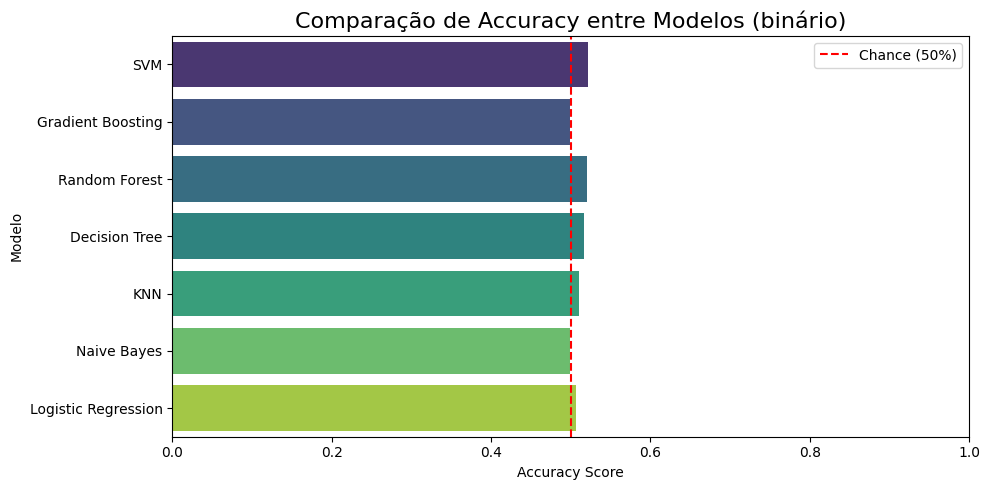

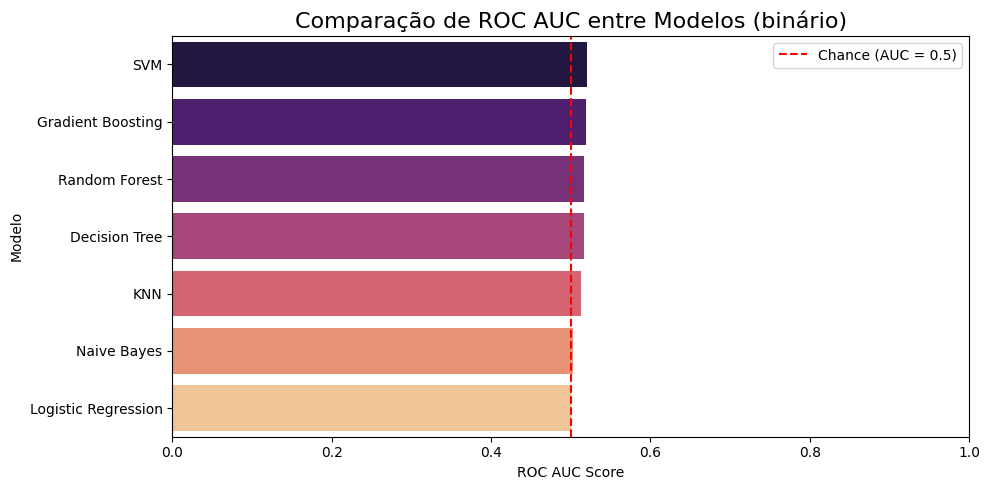


MELHOR MODELO (binário)
Modelo         : SVM
Accuracy       : 0.5220
ROC AUC        : 0.5201


In [77]:
# ============================================================
# VISUALIZAR COMPARAÇÃO ENTRE MODELOS (ACCURACY E ROC AUC)
# ============================================================

plt.figure(figsize=(10, 5))                                    # gráfico de barras de accuracy
sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_bin_df,
    hue='Model',           # necessário nas versões novas do seaborn pra usar palette sem warning
    palette='viridis',
    legend=False
)
plt.title("Comparação de Accuracy entre Modelos (binário)", fontsize=16)
plt.xlabel("Accuracy Score")
plt.ylabel("Modelo")
plt.xlim(0, 1)                                                    # eixo fixo de 0 a 1 pra facilitar comparação visual
plt.axvline(0.5, color='red', linestyle='--', label='Chance (50%)')  # linha de referência do chute aleatório
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))                                    # gráfico de barras de ROC AUC
sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_bin_df,
    hue='Model',
    palette='magma',
    legend=False
)
plt.title("Comparação de ROC AUC entre Modelos (binário)", fontsize=16)
plt.xlabel("ROC AUC Score")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.axvline(0.5, color='red', linestyle='--', label='Chance (AUC = 0.5)')
plt.legend()
plt.show()

# ============================================================
# MELHOR MODELO
# ============================================================

best_model_bin = results_bin_df.sort_values(by='ROC_AUC', ascending=False).iloc[0]  # linha com maior AUC

print("\n" + "="*80)
print("MELHOR MODELO (binário)")
print("="*80)
print(f"Modelo         : {best_model_bin['Model']}")
print(f"Accuracy       : {best_model_bin['Accuracy']:.4f}")
print(f"ROC AUC        : {best_model_bin['ROC_AUC']:.4f}")


                             Feature  Importance
11                Public_Support_Pct    0.054184
8                 Mission_Cost_M_USD    0.053070
6                         Casualties    0.052586
7                Casualties_Rate_Pct    0.052528
3                    Troops_Deployed    0.051464
9               Cost_Per_Soldier_USD    0.051203
4                Air_Assets_Deployed    0.050163
5              Naval_Assets_Deployed    0.045836
0               Operation_Start_Year    0.045248
1                 Operation_End_Year    0.041517
10      Contributing_Countries_Count    0.041447
2                     Duration_Years    0.038912
83                     UN_Mandate_No    0.008112
81                       NATO_Led_No    0.008077
82                      NATO_Led_Yes    0.007881
93    Classification_NATO Restricted    0.007736
80            NATO_Led_Joint UN-NATO    0.007674
92  Classification_NATO Confidential    0.007590
94        Classification_NATO Secret    0.007470
84                  

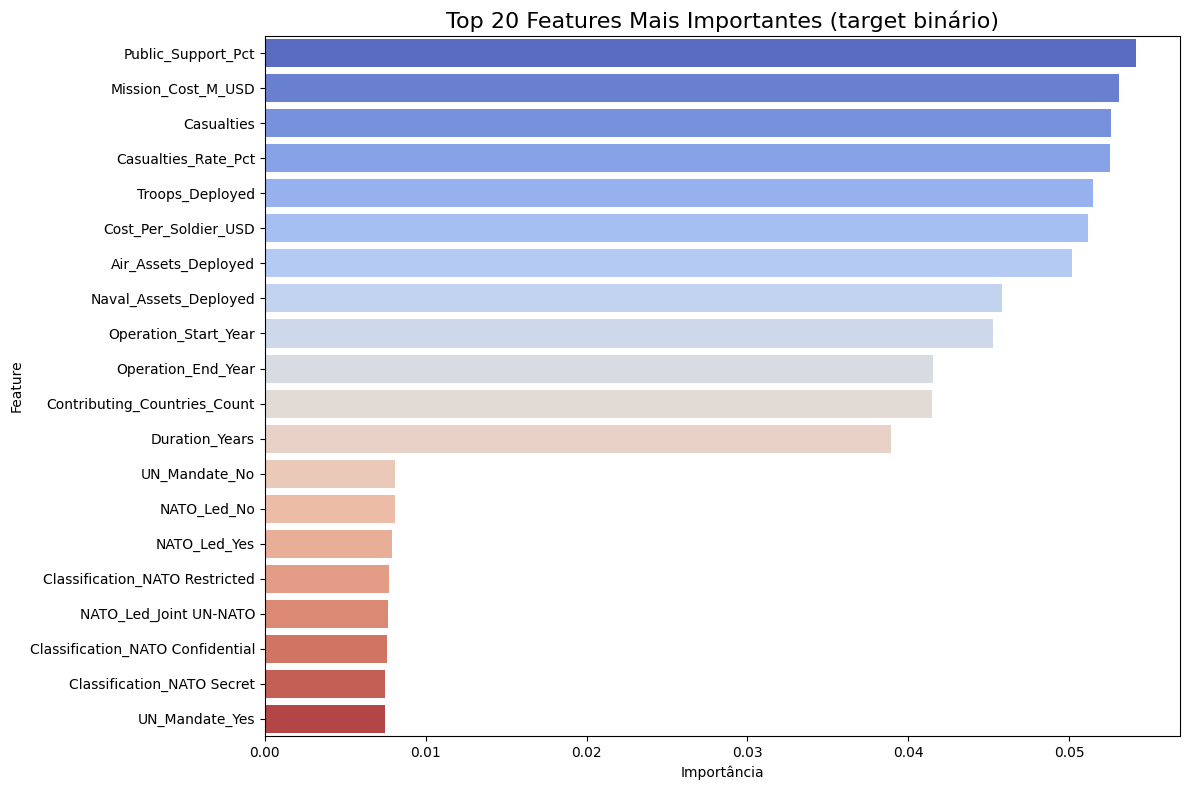

In [78]:

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST) - TARGET BINÁRIO
# ============================================================

# Re-treina um Random Forest sozinho (fora do loop) só pra extrair a importância das features
rf_pipeline_bin = Pipeline(steps=[
    ('preprocessor', preprocessor_bin),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_pipeline_bin.fit(X_train_bin, y_train_bin)                      # treina no conjunto binário

# Recupera os nomes das colunas categóricas depois do one-hot encoding
encoded_cat_features_bin = rf_pipeline_bin.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_columns_bin)

# Junta nomes das colunas numéricas + categóricas codificadas, na mesma ordem usada pelo modelo
all_features_bin = np.concatenate([numerical_columns_bin, encoded_cat_features_bin])

# Importância de cada feature segundo o Random Forest
importances_bin = rf_pipeline_bin.named_steps['model'].feature_importances_

feature_importance_bin_df = pd.DataFrame({
    'Feature': all_features_bin,
    'Importance': importances_bin
}).sort_values(by='Importance', ascending=False).head(20)         # pega só as 20 mais importantes

print(feature_importance_bin_df)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_bin_df,
    hue='Feature',
    palette='coolwarm',
    legend=False
)
plt.title("Top 20 Features Mais Importantes (target binário)", fontsize=16)
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()
